In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler



In [12]:
# Load your dataset
df3 = pd.read_csv("/content/drive/MyDrive/Dataset Water Quality/EDA DS files/Master_Merged (1).csv")
print("Dataset shape:", df.shape)

df.head()

Dataset shape: (240761, 17)


,Area,Waterbody Type,Date,Alkalinity (mg/l),Ammonia (mg/l),Biochemical Oxygen Demand (mg/l),Chloride (mg/l),Conductivity (us/cm),Dissolved Oxygen (% Saturation),Orthophosphate (mg/l),pH (ph units),Temperature (cel),Hardness (mg/l),Nitrogen (mg/l),Nitrate (mg/l),Unnamed: 15,Unnamed: 16
0,"Ballyteigue-Bannow, Adamstown",River,07-07-10,30.0,NaN,NaN,29.0,207.0,66.0,NaN,6.0,11.5,53.0,3.11,5.2,NaN,NaN
1,"Ballyteigue-Bannow, Adamstown",River,14-09-10,NaN,NaN,NaN,40.0,212.0,67.0,NaN,6.5,11.1,50.0,3.39,2.4,NaN,NaN
2,"Ballyteigue-Bannow, Adamstown",River,17-11-10,35.0,NaN,NaN,28.0,212.0,65.0,NaN,6.3,11.0,74.0,3.93,4.5,NaN,NaN
3,"Ballyteigue-Bannow, Adamstown",River,09-03-11,36.0,NaN,NaN,28.0,194.0,67.0,NaN,6.2,10.9,41.0,3.20,4.2,NaN,NaN
4,"Ballyteigue-Bannow, Adamstown",River,29-06-11,32.0,NaN,NaN,28.0,216.0,38.0,NaN,6.2,11.1,57.0,2.70,4.3,NaN,NaN


In [11]:
df2.isnull().sum()

,0
WaterbodyName,0
Years,0
SampleDate,0
Alkalinity-total (as CaCO3),1588
Ammonia-Total (as N),16099
BOD - 5 days (Total),19667
Chloride,2668
Conductivity @25°C,4604
Dissolved Oxygen,293
ortho-Phosphate (as P) - unspecified,12155


In [7]:
df.isnull().sum()


,0
Area,0
Waterbody Type,0
Date,0
Alkalinity (mg/l),74059
Ammonia (mg/l),93374
Biochemical Oxygen Demand (mg/l),133976
Chloride (mg/l),65593
Conductivity (us/cm),80822
Dissolved Oxygen (% Saturation),10024
Orthophosphate (mg/l),79693


In [ ]:
df[['Stress Value', 'Anxiety Value', 'Depression Value']].corr()

,Stress Value,Anxiety Value,Depression Value
Stress Value,1.000000,0.642386,0.584195
Anxiety Value,0.642386,1.000000,0.769706
Depression Value,0.584195,0.769706,1.000000


In [ ]:
df.groupby('Current_CGPA')[['Stress Value','Anxiety Value','Depression Value']].mean()

,Stress Value,Anxiety Value,Depression Value
Current_CGPA,,,
2.50 - 2.99,23.444730,12.856041,14.976864
3.00 - 3.39,22.775300,12.018868,14.238422
3.40 - 3.79,22.780357,12.396429,14.421429
3.80 - 4.00,22.186722,12.074689,13.925311
Below 2.50,24.130952,12.666667,14.642857
Other,24.040936,12.350877,14.444444


In [ ]:
df.groupby('Gender')[['Stress Value','Anxiety Value','Depression Value']].mean()

,Stress Value,Anxiety Value,Depression Value
Gender,,,
Female,24.492659,13.386623,15.554649
Male,22.306050,11.870463,13.892527
Prefer not to say,28.600000,15.200000,20.500000


In [ ]:
df.groupby('waiver_or_scholarship')[['Stress Value','Depression Value']].mean()

,Stress Value,Depression Value
waiver_or_scholarship,,
No,23.055556,14.288390
Yes,22.781690,14.950704


In [ ]:
pd.crosstab(df['Stress Label'], df['Depression Label'])

Depression Label,Mild Depression,Minimal Depression,Moderate Depression,Moderately Severe Depression,No Depression,Severe Depression
Stress Label,,,,,,
High Perceived Stress,13,1,69,183,1,298
Low Stress,48,28,23,10,5,1
Moderate Stress,353,68,365,318,38,206


In [ ]:
df[['Stress Value','Anxiety Value','Depression Value']].corr()

,Stress Value,Anxiety Value,Depression Value
Stress Value,1.000000,0.642386,0.584195
Anxiety Value,0.642386,1.000000,0.769706
Depression Value,0.584195,0.769706,1.000000


In [ ]:
demo_cols = ['Age','Gender','Current_CGPA','Academic_Year','waiver_or_scholarship']

In [ ]:
df.groupby('Academic_Year')['Stress Value'].mean().sort_values()

,Stress Value
Academic_Year,
First Year or Equivalent,22.188020
Other,22.236111
Fourth Year or Equivalent,22.647643
Third Year or Equivalent,23.470175
Second Year or Equivalent,24.081152


In [ ]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()

cat_cols = df_encoded.select_dtypes(include='object').columns

le = LabelEncoder()
for col in cat_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

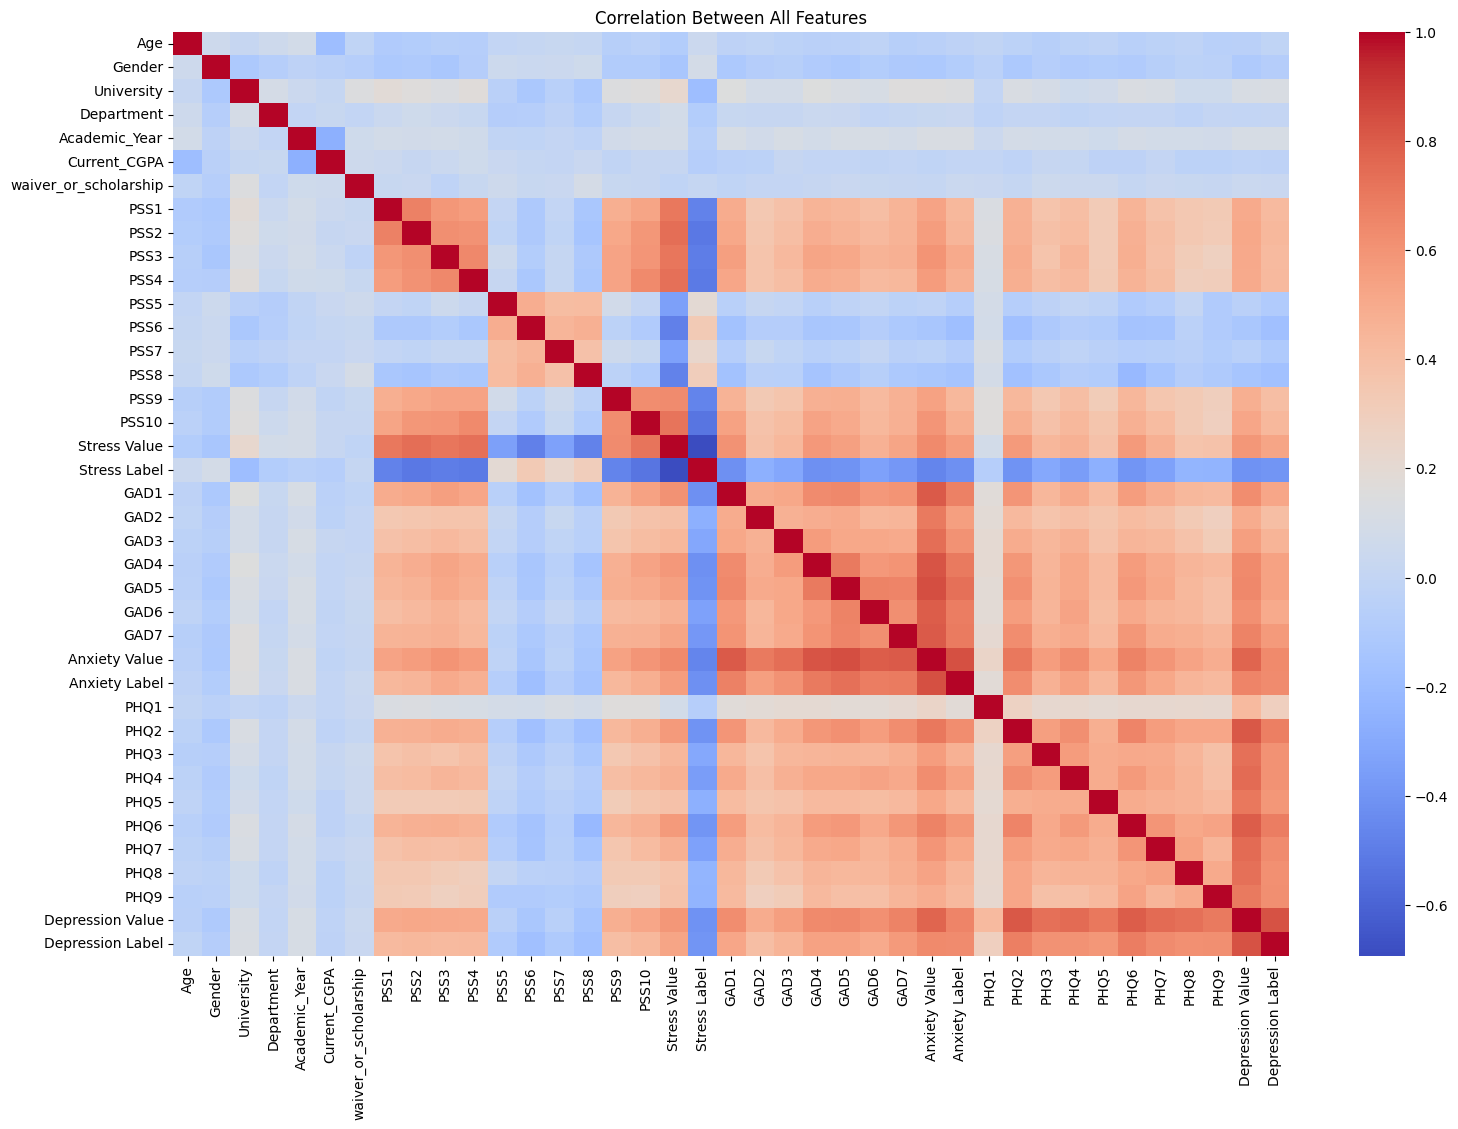

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

corr = df_encoded.corr()

plt.figure(figsize=(18, 12))
sns.heatmap(corr, cmap='coolwarm', annot=False)
plt.title("Correlation Between All Features")
plt.show()

In [ ]:
corr['Stress Value'].sort_values(ascending=False)
corr['Anxiety Value'].sort_values(ascending=False)
corr['Depression Value'].sort_values(ascending=False)

,Depression Value
Depression Value,1.000000
Depression Label,0.832677
PHQ2,0.810137
PHQ6,0.797408
Anxiety Value,0.769706
PHQ7,0.755087
PHQ4,0.750082
PHQ3,0.730538
PHQ8,0.729416
PHQ5,0.706853


In [ ]:
import scipy.stats as stats

groups = [group['Stress Value'].values for name, group in df.groupby('Gender')]
stats.f_oneway(*groups)

F_onewayResult(statistic=np.float64(26.464153453469308), pvalue=np.float64(4.5123111319417534e-12))

In [ ]:
corr = df_encoded.corr()

# Top features for Stress
corr['Stress Value'].sort_values(ascending=False)

# Anxiety
corr['Anxiety Value'].sort_values(ascending=False)

# Depression
corr['Depression Value'].sort_values(ascending=False)

,Depression Value
Depression Value,1.000000
Depression Label,0.832677
PHQ2,0.810137
PHQ6,0.797408
Anxiety Value,0.769706
PHQ7,0.755087
PHQ4,0.750082
PHQ3,0.730538
PHQ8,0.729416
PHQ5,0.706853


ANOVA (numerical feature vs label)

Interpretation:

p < 0.05 → important feature

p ≥ 0.05 → not significant

In [ ]:
import scipy.stats as stats

for col in df.select_dtypes(include='number').columns:
    groups = [group[col].values for name, group in df.groupby('Stress Label')]
    f, p = stats.f_oneway(*groups)
    print(col, "p-value:", p)

PSS1 p-value: 5.241254808113683e-206
PSS2 p-value: 4.323697233762358e-241
PSS3 p-value: 8.386893469017129e-222
PSS4 p-value: 2.5010947208877917e-231
PSS5 p-value: 1.1920604389706803e-37
PSS6 p-value: 6.001627076756933e-89
PSS7 p-value: 7.408915420232715e-45
PSS8 p-value: 1.883132163581211e-80
PSS9 p-value: 1.0471908134646941e-164
PSS10 p-value: 1.899172011354833e-229
Stress Value p-value: 0.0
GAD1 p-value: 1.9076508523731922e-146
GAD2 p-value: 4.6999893048265655e-55
GAD3 p-value: 1.5861669899707026e-71
GAD4 p-value: 1.4112590964740602e-134
GAD5 p-value: 1.854543722473856e-115
GAD6 p-value: 2.548291552924907e-78
GAD7 p-value: 1.1696209083368794e-108
Anxiety Value p-value: 9.199299223481897e-169
PHQ1 p-value: 0.009096223338113552
PHQ2 p-value: 4.759158369352136e-126
PHQ3 p-value: 2.0313939404376874e-66
PHQ4 p-value: 1.5921850362191479e-86
PHQ5 p-value: 6.503477306540818e-50
PHQ6 p-value: 1.8236726341336624e-130
PHQ7 p-value: 2.6088490763663634e-86
PHQ8 p-value: 3.924500025547193e-43
PHQ9

Chi-Square (categorical vs label)

In [ ]:
from sklearn.feature_selection import chi2
from sklearn.preprocessing import LabelEncoder

df_cat = df.copy()

for col in df_cat.select_dtypes(include='object').columns:
    df_cat[col] = LabelEncoder().fit_transform(df_cat[col])

X = df_cat.drop(columns=['Stress Label'])
y = df_cat['Stress Label']

chi_scores = chi2(X, y)

import pandas as pd
chi_df = pd.DataFrame({
    'Feature': X.columns,
    'Score': chi_scores[0],
    'p-value': chi_scores[1]
})

chi_df.sort_values(by='Score', ascending=False)

,Feature,Score,p-value
17,Stress Value,3073.352768,0.000000e+00
36,Depression Value,1582.974498,0.000000e+00
25,Anxiety Value,1573.767208,0.000000e+00
37,Depression Label,538.373943,1.240462e-117
10,PSS4,521.965606,4.535330e-114
8,PSS2,490.832438,2.612704e-107
16,PSS10,459.307732,1.830599e-100
7,PSS1,447.197158,7.804966e-98
26,Anxiety Label,384.062316,3.998782e-84
9,PSS3,379.252939,4.428644e-83


Model-Based Feature Importance (BEST METHOD)

Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

df_model = df.copy()

# Encode categorical
for col in df_model.select_dtypes(include='object').columns:
    df_model[col] = LabelEncoder().fit_transform(df_model[col])

X = df_model.drop(columns=['Stress Label'])
y = df_model['Stress Label']

model = RandomForestClassifier()
model.fit(X, y)

importances = model.feature_importances_

feat_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

feat_imp.head(10)

,Feature,Importance
17,Stress Value,0.423292
16,PSS10,0.077198
10,PSS4,0.065756
9,PSS3,0.065144
8,PSS2,0.053091
15,PSS9,0.039647
12,PSS6,0.032516
7,PSS1,0.031474
14,PSS8,0.024725
13,PSS7,0.021864


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

df_model = df.copy()

# Encode categorical
for col in df_model.select_dtypes(include='object').columns:
    df_model[col] = LabelEncoder().fit_transform(df_model[col])

X = df_model.drop(columns=['Anxiety Label'])
y = df_model['Anxiety Label']

model = RandomForestClassifier()
model.fit(X, y)

importances = model.feature_importances_

feat_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

feat_imp.head(10)

,Feature,Importance
26,Anxiety Value,0.378963
23,GAD5,0.105459
22,GAD4,0.068751
24,GAD6,0.058246
19,GAD1,0.057798
25,GAD7,0.050212
21,GAD3,0.048508
20,GAD2,0.045520
36,Depression Value,0.027285
28,PHQ2,0.014738


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

df_model = df.copy()

# Encode categorical
for col in df_model.select_dtypes(include='object').columns:
    df_model[col] = LabelEncoder().fit_transform(df_model[col])

X = df_model.drop(columns=['Depression Label'])
y = df_model['Depression Label']

model = RandomForestClassifier()
model.fit(X, y)

importances = model.feature_importances_

feat_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

feat_imp.head(10)

,Feature,Importance
37,Depression Value,0.404878
33,PHQ6,0.060319
29,PHQ2,0.059938
36,PHQ9,0.049714
34,PHQ7,0.045684
31,PHQ4,0.044415
30,PHQ3,0.038991
35,PHQ8,0.034613
32,PHQ5,0.031827
26,Anxiety Value,0.028171


**Implement PCA**

In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
import pandas as pd

# Copy dataset
df_pca = df.copy()

# Encode categorical columns
le = LabelEncoder()
for col in df_pca.select_dtypes(include='object').columns:
    df_pca[col] = le.fit_transform(df_pca[col])

# Drop target columns (IMPORTANT)
target_cols = [
    'Stress Value', 'Stress Label',
    'Anxiety Value', 'Anxiety Label',
    'Depression Value', 'Depression Label'
]

X = df_pca.drop(columns=target_cols)

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
from sklearn.decomposition import PCA

# Keep all components first
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

Explained Variance (MOST IMPORTANT)

Choose components where variance ≥ 90–95%

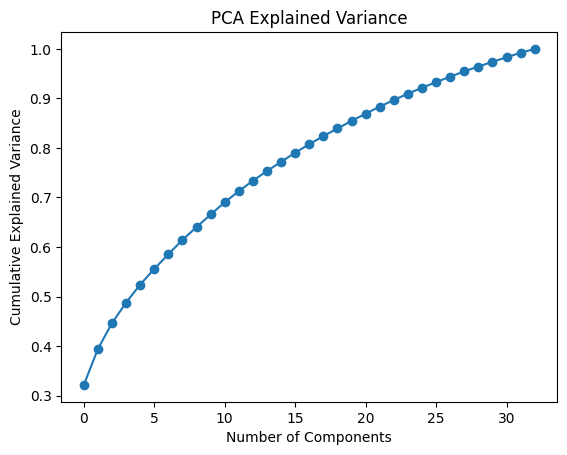

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

explained_var = pca.explained_variance_ratio_
cum_var = np.cumsum(explained_var)

plt.plot(cum_var, marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.show()

In [ ]:
n_components = np.argmax(cum_var >= 0.95) + 1
print("Optimal components:", n_components)

Optimal components: 28


PCA with Selected Components

In [ ]:
pca = PCA(n_components=n_components)
X_reduced = pca.fit_transform(X_scaled)

print("Reduced shape:", X_reduced.shape)

Reduced shape: (2028, 28)


eature Importance from PCA (KEY PART)

In [ ]:
# PCA loadings
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(n_components)],
    index=X.columns
)

# View top contributing features for PC1
loadings['PC1'].sort_values(ascending=False)

,PC1
PHQ2,0.245305
GAD5,0.241008
GAD4,0.240386
GAD1,0.239157
PHQ6,0.237371
GAD7,0.236165
GAD6,0.223702
PHQ4,0.220016
PSS3,0.217189
PSS10,0.216475


In [ ]:
# Sum of absolute loadings across components
loadings['Importance'] = loadings.abs().sum(axis=1)

# Sort features
important_features = loadings['Importance'].sort_values(ascending=False)

important_features.head(28)

,Importance
PHQ8,16.716721
PHQ9,16.708818
GAD3,16.504493
PHQ5,16.269311
PSS9,16.085105
GAD2,15.932487
PHQ3,15.396269
PHQ7,15.268746
PHQ4,14.083744
GAD6,13.609654


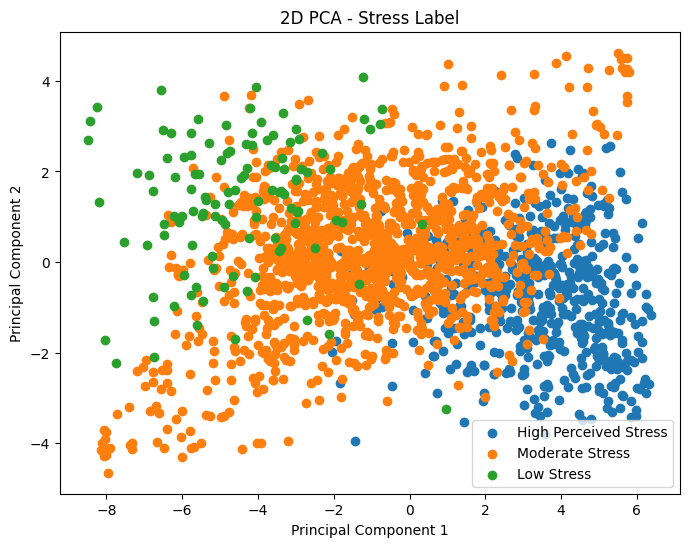

In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Apply PCA (2 components)
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

# Create DataFrame for plotting
pca_df = pd.DataFrame(X_pca_2d, columns=['PC1', 'PC2'])

# Add label (choose one)
pca_df['Stress Label'] = df['Stress Label']

# Plot
plt.figure(figsize=(8,6))

for label in pca_df['Stress Label'].unique():
    subset = pca_df[pca_df['Stress Label'] == label]
    plt.scatter(subset['PC1'], subset['PC2'], label=label)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("2D PCA - Stress Label")
plt.legend()
plt.show()

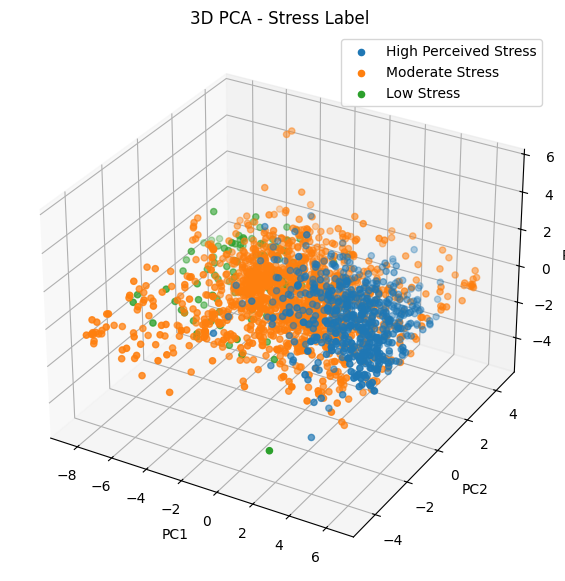

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

# Apply PCA (3 components)
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)

# DataFrame
pca_df_3d = pd.DataFrame(X_pca_3d, columns=['PC1', 'PC2', 'PC3'])
pca_df_3d['Stress Label'] = df['Stress Label']

# Plot
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

for label in pca_df_3d['Stress Label'].unique():
    subset = pca_df_3d[pca_df_3d['Stress Label'] == label]
    ax.scatter(subset['PC1'], subset['PC2'], subset['PC3'], label=label)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("3D PCA - Stress Label")
ax.legend()

plt.show()

In [ ]:
pca_df['Anxiety Label'] = df['Anxiety Label']
# OR
pca_df['Depression Label'] = df['Depression Label']

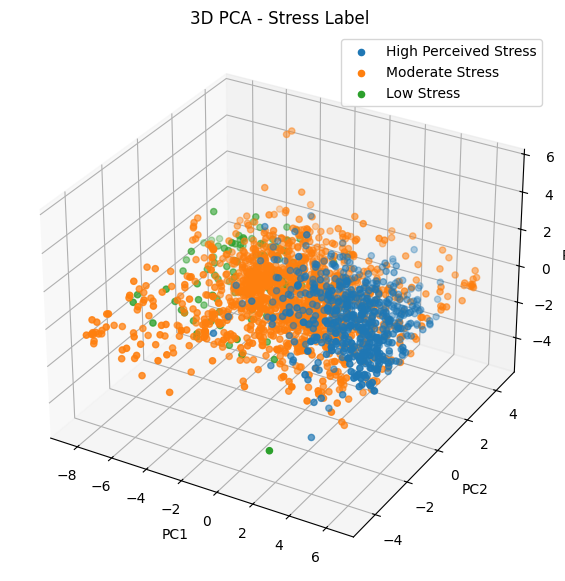

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

# Apply PCA (3 components)
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)

# DataFrame
pca_df_3d = pd.DataFrame(X_pca_3d, columns=['PC1', 'PC2', 'PC3'])
pca_df_3d['Stress Label'] = df['Stress Label']

# Plot
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

for label in pca_df_3d['Stress Label'].unique():
    subset = pca_df_3d[pca_df_3d['Stress Label'] == label]
    ax.scatter(subset['PC1'], subset['PC2'], subset['PC3'], label=label)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("3D PCA - Stress Label")
ax.legend()

plt.show()

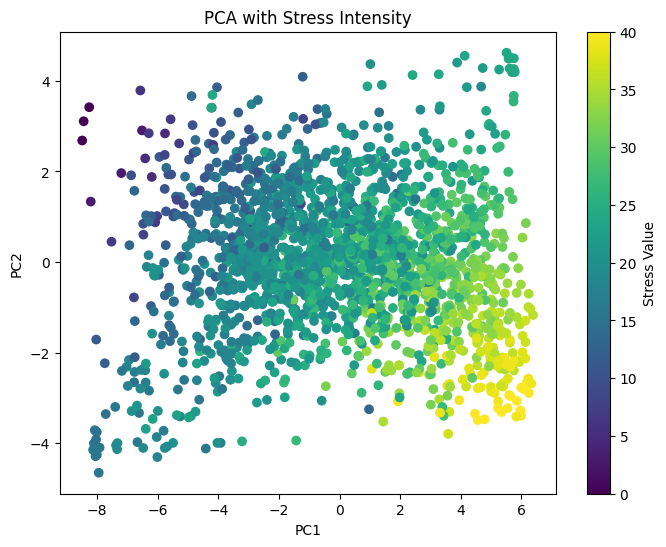

In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# PCA (2D)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot with gradient
plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=df['Stress Value'],   # continuous color
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA with Stress Intensity")
plt.colorbar(scatter, label='Stress Value')

plt.show()

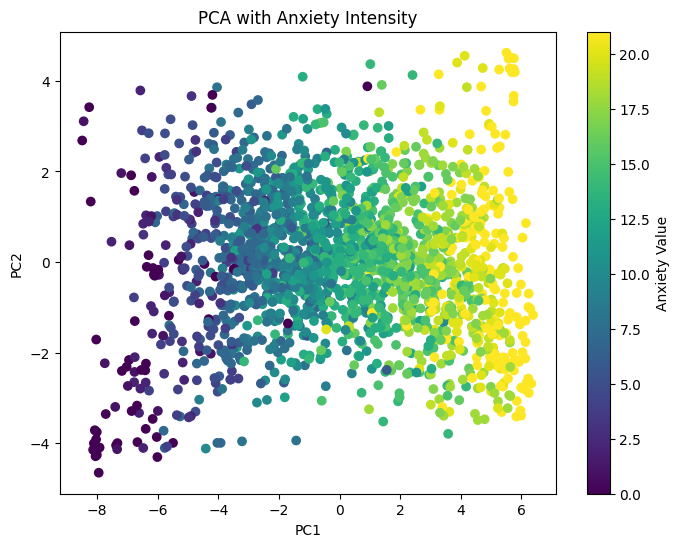

In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# PCA (2D)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot with gradient
plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=df['Anxiety Value'],   # continuous color
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA with Anxiety Intensity")
plt.colorbar(scatter, label='Anxiety Value')

plt.show()

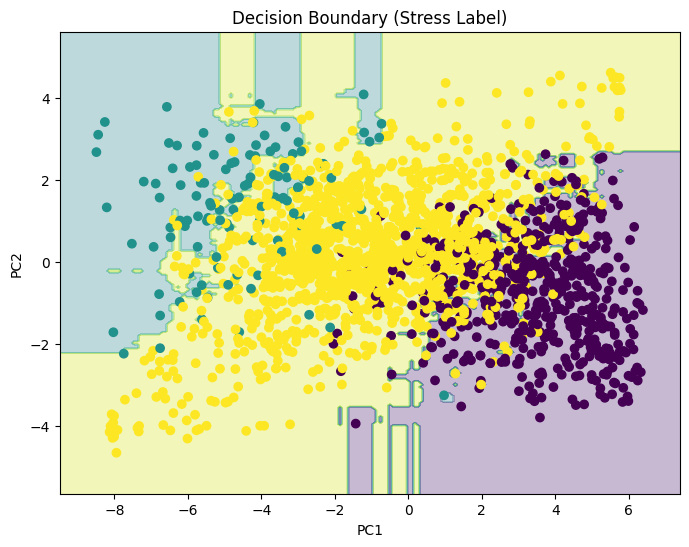

In [ ]:
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

# Encode labels
le = LabelEncoder()
y = le.fit_transform(df['Stress Label'])

# PCA to 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Train model
model = RandomForestClassifier()
model.fit(X_pca, y)

# Create mesh grid
x_min, x_max = X_pca[:,0].min() - 1, X_pca[:,0].max() + 1
y_min, y_max = X_pca[:,1].min() - 1, X_pca[:,1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot
plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.3)

plt.scatter(X_pca[:,0], X_pca[:,1], c=y)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Decision Boundary (Stress Label)")
plt.show()

t-SNE Visualization (Better than PCA for Clusters)

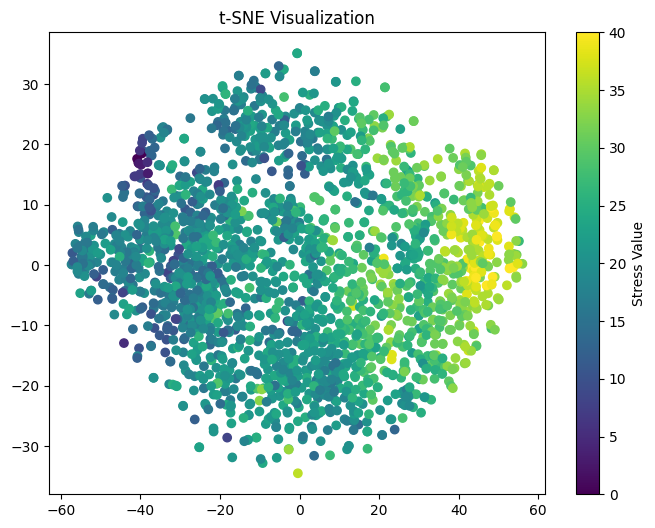

In [ ]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

plt.scatter(
    X_tsne[:,0],
    X_tsne[:,1],
    c=df['Stress Value']   # or use labels
)

plt.colorbar(label='Stress Value')
plt.title("t-SNE Visualization")
plt.show()

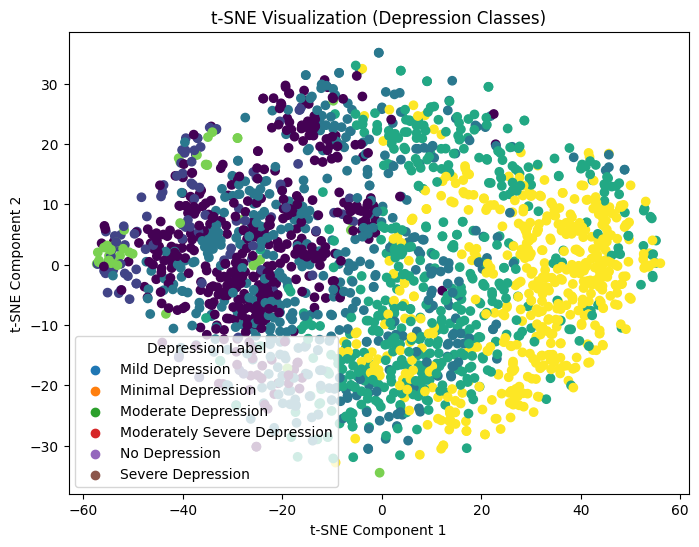

In [ ]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import LabelEncoder

# Encode Depression Label (target)
le = LabelEncoder()
y = le.fit_transform(df['Depression Label'])

# Apply t-SNE
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

# Plot
plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=y
)

# Add legend manually
handles = []
labels = le.classes_

for i, label in enumerate(labels):
    handles.append(
        plt.scatter([], [], label=label)
    )

plt.legend(handles=handles, title="Depression Label")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.title("t-SNE Visualization (Depression Classes)")

plt.show()

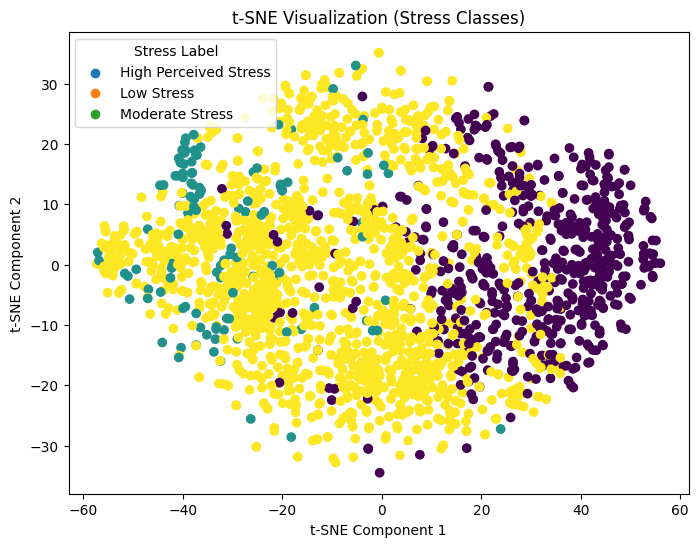

In [ ]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import LabelEncoder

# Encode Depression Label (target)
le = LabelEncoder()
y = le.fit_transform(df['Stress Label'])

# Apply t-SNE
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

# Plot
plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=y
)

# Add legend manually
handles = []
labels = le.classes_

for i, label in enumerate(labels):
    handles.append(
        plt.scatter([], [], label=label)
    )

plt.legend(handles=handles, title="Stress Label")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.title("t-SNE Visualization (Stress Classes)")

plt.show()

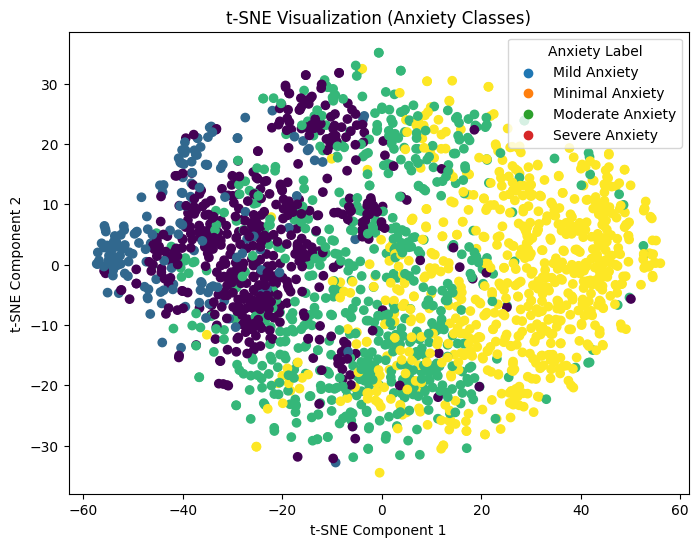

In [ ]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import LabelEncoder

# Encode Depression Label (target)
le = LabelEncoder()
y = le.fit_transform(df['Anxiety Label'])

# Apply t-SNE
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

# Plot
plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=y
)

# Add legend manually
handles = []
labels = le.classes_

for i, label in enumerate(labels):
    handles.append(
        plt.scatter([], [], label=label)
    )

plt.legend(handles=handles, title="Anxiety Label")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.title("t-SNE Visualization (Anxiety Classes)")

plt.show()

UMAP Visualization (Even More Powerful)

In [ ]:
pip install umap-learn

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


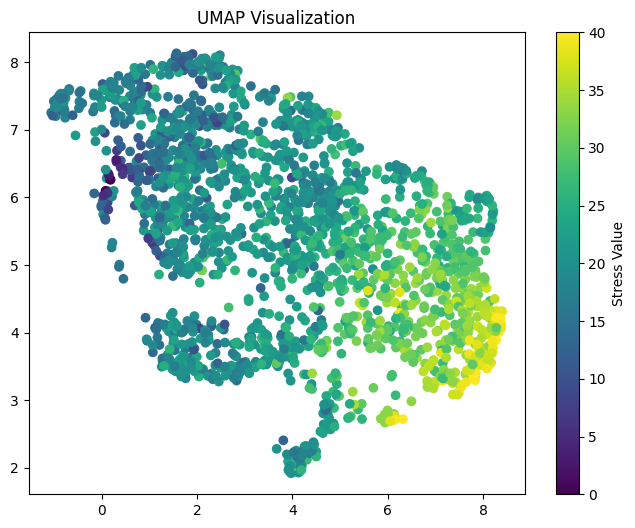

In [ ]:
import umap.umap_ as umap

umap_model = umap.UMAP(n_components=2, random_state=42)
X_umap = umap_model.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

plt.scatter(
    X_umap[:,0],
    X_umap[:,1],
    c=df['Stress Value']
)

plt.colorbar(label='Stress Value')
plt.title("UMAP Visualization")
plt.show()

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Copy dataset
df_corr = df.copy()

# Encode labels
le_stress = LabelEncoder()
le_anxiety = LabelEncoder()
le_depression = LabelEncoder()

df_corr['Stress Label Encoded'] = le_stress.fit_transform(df_corr['Stress Label'])
df_corr['Anxiety Label Encoded'] = le_anxiety.fit_transform(df_corr['Anxiety Label'])
df_corr['Depression Label Encoded'] = le_depression.fit_transform(df_corr['Depression Label'])

# Compute correlations
stress_corr = df_corr['Stress Value'].corr(df_corr['Stress Label Encoded'])
anxiety_corr = df_corr['Anxiety Value'].corr(df_corr['Anxiety Label Encoded'])
depression_corr = df_corr['Depression Value'].corr(df_corr['Depression Label Encoded'])

print("Stress Value vs Stress Label Correlation:", stress_corr)
print("Anxiety Value vs Anxiety Label Correlation:", anxiety_corr)
print("Depression Value vs Depression Label Correlation:", depression_corr)

Stress Value vs Stress Label Correlation: -0.6930745637465494
Anxiety Value vs Anxiety Label Correlation: 0.8401351063069424
Depression Value vs Depression Label Correlation: 0.832676619790491


In [ ]:
results = pd.DataFrame({
    'Metric': ['Stress', 'Anxiety', 'Depression'],
    'Correlation': [stress_corr, anxiety_corr, depression_corr]
})

print(results)

       Metric  Correlation
0      Stress    -0.693075
1     Anxiety     0.840135
2  Depression     0.832677


In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Copy dataset
df_corr = df.copy()

# Encode labels
le = LabelEncoder()

df_corr['Stress Label Encoded'] = le.fit_transform(df_corr['Stress Label'])
df_corr['Anxiety Label Encoded'] = le.fit_transform(df_corr['Anxiety Label'])
df_corr['Depression Label Encoded'] = le.fit_transform(df_corr['Depression Label'])

# Select only relevant columns
corr_matrix = df_corr[[
    'Stress Value', 'Stress Label Encoded',
    'Anxiety Value', 'Anxiety Label Encoded',
    'Depression Value', 'Depression Label Encoded'
]].corr()

print(corr_matrix)

                          Stress Value  Stress Label Encoded  Anxiety Value  \
Stress Value                  1.000000             -0.693075       0.642386   
Stress Label Encoded         -0.693075              1.000000      -0.461633   
Anxiety Value                 0.642386             -0.461633       1.000000   
Anxiety Label Encoded         0.557200             -0.420274       0.840135   
Depression Value              0.584195             -0.410169       0.769706   
Depression Label Encoded      0.529740             -0.400030       0.638555   

                          Anxiety Label Encoded  Depression Value  \
Stress Value                           0.557200          0.584195   
Stress Label Encoded                  -0.420274         -0.410169   
Anxiety Value                          0.840135          0.769706   
Anxiety Label Encoded                  1.000000          0.660762   
Depression Value                       0.660762          1.000000   
Depression Label Encoded        

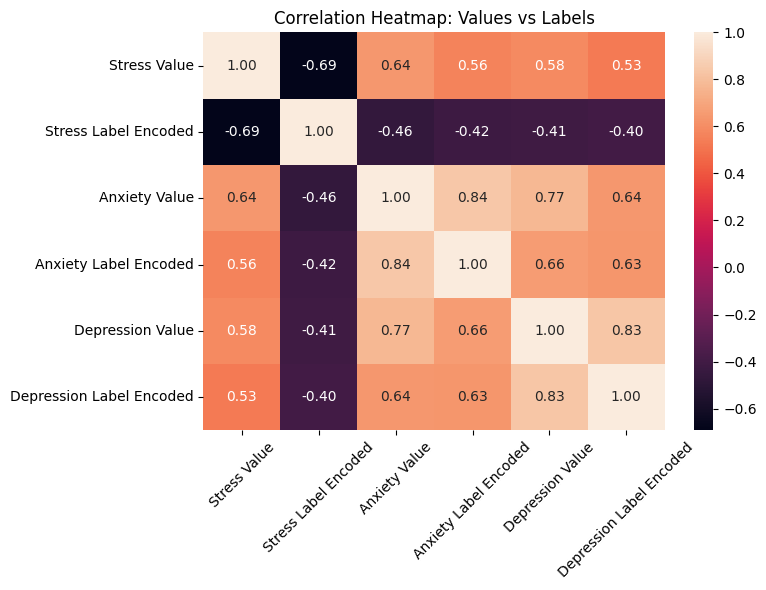

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

# Copy dataset
df_corr = df.copy()

# Encode labels separately (important)
le_stress = LabelEncoder()
le_anxiety = LabelEncoder()
le_depression = LabelEncoder()

df_corr['Stress Label Encoded'] = le_stress.fit_transform(df_corr['Stress Label'])
df_corr['Anxiety Label Encoded'] = le_anxiety.fit_transform(df_corr['Anxiety Label'])
df_corr['Depression Label Encoded'] = le_depression.fit_transform(df_corr['Depression Label'])

# Select relevant columns
cols = [
    'Stress Value', 'Stress Label Encoded',
    'Anxiety Value', 'Anxiety Label Encoded',
    'Depression Value', 'Depression Label Encoded'
]

# Correlation matrix
corr_matrix = df_corr[cols].corr()

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Heatmap: Values vs Labels")
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()